In [1]:
from pyuvdata import UVData, UVBeam, utils as uvutils
import numpy as np
import hdf5plugin
import copy
import uvtools as uvt
import matplotlib.pyplot as plt
import hera_cal as hc
# import healvis
from scipy.signal import windows

import astropy.io.fits as fits
import pandas as pd
import h5py
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
import glob
import os
from scipy import stats
import hera_pspec as hp
import astropy
from astropy.time import Time
from astropy.coordinates import get_sun
import astropy.units as u

In [2]:
t = Time("2024-12-05 2:27:24.3", scale="utc")

# Get Sun position (GCRS frame by default)
sun = get_sun(t)

# Convert to ICRS for RA/Dec
sun_icrs = sun.icrs

print(f"RA  = {sun_icrs.ra.to(u.hourangle):.2f}")
print(f"Dec = {sun_icrs.dec.to(u.deg):.2f}")

RA  = 14.48 hourangle
Dec = -13.22 deg


In [3]:
import glob
import re
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"
path_data2="/net/sinatra/vault2/ntsikelelo/Data_H6C/"
def numerical_sort(value):
    # Find all digit groups and convert them to integers
    numbers = re.findall(r'\d+', value)
    return list(map(int, numbers)) if numbers else [0]

uvh5name = sorted(glob.glob(path_data2+"*sum.uvh5"), key=numerical_sort)
# files_diff=files = sorted(glob.glob(path_data+"*diff.uvh5"), key=numerical_sort)

In [4]:
uvh5name[4*275]

'/net/sinatra/vault2/ntsikelelo/Data_H6C/zen.2459861.49903.sum.uvh5'

In [5]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read(Model_complete_file, read_data=False)  
pol=uvd1.polarization_array[0]
uvd1.read(Model_complete_file, polarizations=pol) 
antpos=uvd1.antenna_positions
ants=uvd1.antenna_numbers
antpos_d = dict(zip(ants, antpos))

#make redundant groups model        
reds = hc.redcal.get_pos_reds(antpos_d, include_autos=True)

In [6]:

filter_name="Main_lobe_20_mHz"
filter_name_2="Notch_filter_40_mHz"
filter_name_3="Notch_filter_80_mHz"
filter_name_4="Main_lobe_baseline_dependent"
filter_name_5="Notch_filter_20_mHz"
lst="0h"
spw="low"

In [7]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/Full_LST_gleam_model_final_"+lst+"_"+spw+".uvh5", read_data=False)
lsts=np.rad2deg(np.unique(uvd1.lst_array))*(24/360)
freqs = uvd1.freq_array*1e-6
dt=((lsts[1]-lsts[0])*60*60)/4
# t_total=(800*dt)/2
# t_total/3600

antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.


In [8]:
dt

np.float64(19.38026895248957)

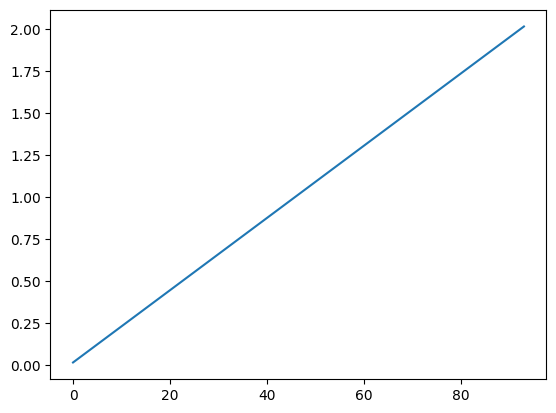

In [10]:
plt.plot(lsts[lsts<10])

In [11]:

def JytomK(Jy, f0=163e6):
    """Convert Jansky to mK

    Args:
        Jy (float): brightness in Jy
        f0 (float): frequency in Hz

    Returns:
        float: brightness temperature in mK
    """

    # wavelength in m
    c=3.0e8
    lam = c / f0

    # flux density in W/m^2/Hz
    S = Jy * 1e-26
    kb=1.38064852e-23
    # temperature in K
    T = S * lam ** 2 / (2 * kb)

    # rettourn temperature in mK
    return T * 1e3

def power_spectrum(V, baseline, f1, df, delays):
    window = windows.blackmanharris(delays.shape[0])
    comso=hp.conversions.Cosmo_Conversions(Om_l=0.7,H0=70,Om_c=0.3)
    c=3e8
   
    f0=1420.0e6
    lambda_0=c/f0
    lambda_1=c/f1

    z=(lambda_1-lambda_0)/lambda_0
    factor=comso.bl_to_kperp(z=z)
    theta=(lambda_1/baseline)
    Dc=comso.dRperp_dtheta(z)*theta
    Beff=np.sum(window*df)
    Delta_D=comso.dRpara_df(z)*Beff
    k_par=comso.tau_to_kpara(z=z)*delays*1e-9
    k_per=factor*baseline
    theta_d=np.rad2deg(theta)
    Ae=theta_d**2
    

    steradian=(180.0/np.pi)**2 #degrees per steradian
    Omega= Ae/steradian
    V_mk=JytomK(Jy=V,f0=f1)
    constant=((Dc**2*Delta_D)/(Beff))*(1/(Omega*Beff))
    P=V_mk**2*constant*df**2
    
    print(" at redshift "+str(z))
    return k_par,np.array(P)
def vis_perform_delay_trans(freqs=freqs, data=""):

    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=windows.blackmanharris(len(freqs))
    
    
    
    print(len(data))
    data_full_bls=[]
    for t in range(len(data)):
        # print(t)
       
        for bls in range (len(data[t])):
            data_time_no_nans=data[t][bls][~np.isnan(data[t][bls])]
            freq_no_nans=freqs[~np.isnan(data[t][bls])]
            coeffs = np.polyfit(freq_no_nans, data_time_no_nans, 6)
            poly = np.poly1d(coeffs)
            x_fit=freqs
            y_fit=poly(x_fit)
            data_fitted=[]
            for i in range (data[t][bls].shape[0]):
                if np.isnan(data[t][bls][i]):
                    data_fitted.append(poly(x_fit[i]))
                else:
                    data_fitted.append(data[t][bls][i])
            data_fitted=np.array(data_fitted) 
           
            data_full_bls.append(data_fitted)
            
    data_full_bls=np.array(data_full_bls)
    print(data_full_bls.shape)
    # data_full_fitted=np.array(data_full_fitted)
    cross_power=[]
    for i in range (data_full_bls.shape[0]-1):
        # for k in range (130):
        #     if k>i:
               
                g0_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[i]))
                g1_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[i+1]))
                cross_power.append(g0_delay*np.conjugate(g1_delay))
                # cross_power.append(np.abs(g0_delay))
                
    cross_power=np.array(cross_power)
    kpar, power_spectrum_cross_power=power_spectrum(V=cross_power, baseline=14.5, f1=62.5e6, df=122e3, delays=tau)
    return data_full_bls, power_spectrum_cross_power, kpar

In [12]:
hd = io.HERAData(uvh5name[20])
# antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
# antpos_d = dict(zip(ants, antpos))
reds = redcal.get_reds(hd.data_antpos, pols=['nn'], pol_mode='1pol')

In [13]:
N=100

def filter_data(cal_data):
    flag_low=67.85
    flag_high=71.20
    index_flag=np.where((freqs>=flag_low ) & (freqs<=flag_high) )
    index_flag2=np.where((freqs>=55 ) & (freqs<=63) )

    
    cal_data_filtered=[]
    for bl in cal_data:
        blvec = (antpos[np.where(ants==bl[0])] - antpos[np.where(ants==bl[1])])
        
        if np.abs(np.linalg.norm(blvec)-14)<2:

            
            cal_data_flagged=np.array(cal_data[bl][0,:])
            cal_data_flagged[index_flag]=np.nan*(np.ones(cal_data_flagged[index_flag].shape))
            # cal_data_flagged[index_flag2]=np.nan*(np.ones(cal_data_flagged[index_flag2].shape))
            cal_data_filtered.append(cal_data_flagged)
    
    return cal_data_filtered
    
def extrac_cal_data(file_name=path_data+"abs_calibrated_data_full_", lst="0h", spw="low", uvh5name=uvh5name, N=N):

    k=0
    cal_all_data=[]
    for x in range(N):
        n=k+x 
        
        if (n!=64 and n!=63 and n!=22 and n!=21 and n!=19 and n!=18): 
  
            i=4*n
            cal_data = np.load(file_name+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy", allow_pickle=True).item()
            cal_all_data.append(filter_data(cal_data))  
                
    for x in range(N):
        n=k+x 
        
        if (n!=64 and n!=63 and n!=22 and n!=21 and n!=19 and n!=18): 
            i=4*n+1
    
            cal_data = np.load(file_name+uvh5name[i][43:69]+"_1h_"+spw+".npy", allow_pickle=True).item()
    
            cal_all_data.append(filter_data(cal_data))


    for x in range(N):
        n=k+x 
        if (n!=64 and n!=63 and n!=22 and n!=21 and n!=19 and n!=18): 
            # print(n)
            i=4*n+2
        
            cal_data = np.load(file_name+uvh5name[i][43:69]+"_2h_"+spw+".npy", allow_pickle=True).item()
        
            cal_all_data.append(filter_data(cal_data))    

    for x in range(N):
        n=k+x
        if n!=4 and n!=5 and n!=6 and n!=19 and n!=18: 
            i=4*n+3
   
        
            cal_data = np.load(file_name+uvh5name[i][43:69]+"_3h_"+spw+".npy", allow_pickle=True).item()
        
            cal_all_data.append(filter_data(cal_data))         

  
    return cal_all_data        

In [14]:
lsts[0], lsts[200]

(np.float64(0.014352717191858355), np.float64(22.937671209612187))

In [15]:
cal_data_full=extrac_cal_data(file_name=path_data+"abs_calibrated_data_full_",lst=lst , spw=spw,  uvh5name=uvh5name, N=N)
#cal_data_full_filter=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name+"_full_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
#cal_data_full_filter_notch=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_2+"_full_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

# cal_data_gleam_filter=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)


cal_data_gleam_filter_notch=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_2+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
cal_data_gleam=extrac_cal_data(file_name=path_data+"abs_calibrated_data_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

# #cal_data_gleam_filter_notch_80_mHz=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_3+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

# cal_data_gleam_filter_main_lobe_baseline_dependent=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_4+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

cal_data_gleam_filter_notch_20_mHz=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_5+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

In [16]:
#70 to 95
n=0
c, p, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam)
# # c2, p2, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full_filter)
# c3, p3, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter)
c4, p4, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full)

c5, p5, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_notch)
# # c6, p6, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full_filter_notch)

# c7, p7, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_notch_80_mHz)

# c8, p8, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_main_lobe_baseline_dependent)

c9, p9, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_notch_20_mHz)

377
(34786, 205)
 at redshift 21.72
377
(34786, 205)
 at redshift 21.72
377
(34757, 205)
 at redshift 21.72
377
(34783, 205)
 at redshift 21.72


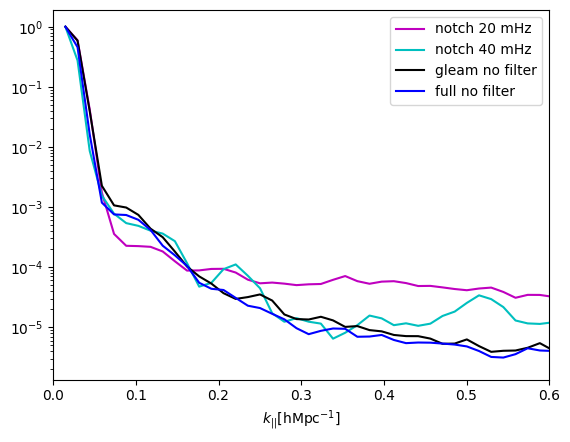

In [20]:

def take_mean_and_fold(tau, p):
    p_ave_in= np.mean(p, axis=0)
    p_ave=p_ave_in/np.max(np.abs(p_ave_in))
    # p_fold=np.zeros(p_ave.shape[0]/2)
    
    p_fold=[]
    
    for n in range (102):
        
        i=102-n
        p1=np.abs(p_ave[tau==tau[i]])
        p2=np.abs(p_ave[tau==-tau[i]])
        p_fold.append((p1+p2)/2)
            
    
    p_fold=np.array(p_fold)
    p_fold_complete=np.zeros(shape=(p_fold.shape[0]+1), dtype=complex)
    p_fold_complete[1:]=p_fold[:,0]
    p_fold_complete[0]=1
    return p_fold
    
    
p_ave= take_mean_and_fold(tau, p)
# p_ave2= take_mean_and_fold(tau, p2)
# p_ave3= take_mean_and_fold(tau, p3)
p_ave4= take_mean_and_fold(tau, p4)
p_ave5= take_mean_and_fold(tau, p5)
# p_ave6= take_mean_and_fold(tau, p6)
# p_ave7= take_mean_and_fold(tau, p7)
# p_ave8= take_mean_and_fold(tau, p8)
p_ave9= take_mean_and_fold(tau, p9)
# plt.semilogy(tau[tau>=0], np.abs(p_test),'g', label="notch gleam")
plt.plot(tau[tau>0], np.abs(p_ave9)/np.max(np.abs(p_ave9)),'m', label="notch 20 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave8)/np.max(np.abs(p_ave8)),'r', label="Main lobe baseline dependent")
# plt.plot(tau[tau>0], np.abs(p_ave7)/np.max(np.abs(p_ave7)),'b', label="notch 80 mHz")
plt.semilogy(tau[tau>0], np.abs(p_ave5),'c', label="notch 40 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave6)/np.max(np.abs(p_ave6)),'y', label="notch full")
plt.semilogy(tau[tau>0], np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="gleam no filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave2)/np.max(np.abs(p_ave2)),'m', label="full filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="Main lobe 40 mHz")
plt.semilogy(tau[tau>0], np.abs(p_ave4)/np.max(np.abs(p_ave4)),'b', label="full no filter")
plt.xlabel("$k_{||}\mathrm{[h Mpc^{-1}]}$")
plt.xlim([0,0.6])
plt.legend()


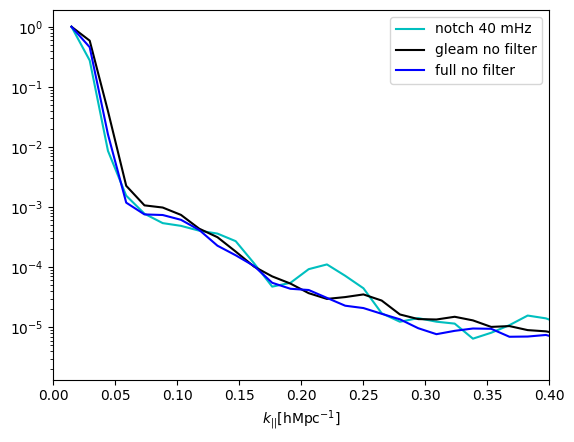

In [21]:
p_ave= take_mean_and_fold(tau, p)
# p_ave2= take_mean_and_fold(tau, p2)
# p_ave3= take_mean_and_fold(tau, p3)
p_ave4= take_mean_and_fold(tau, p4)
p_ave5= take_mean_and_fold(tau, p5)
# p_ave6= take_mean_and_fold(tau, p6)
# p_ave7= take_mean_and_fold(tau, p7)
# p_ave8= take_mean_and_fold(tau, p8)
# p_ave9= take_mean_an..._fold(tau, p9)
# plt.semilogy(tau[tau>=0], np.abs(p_test),'g', label="notch gleam")
# plt.plot(tau[tau>0], np.abs(p_ave9)/np.max(np.abs(p_ave9)),'m', label="notch 20 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave8)/np.max(np.abs(p_ave8)),'r', label="Main lobe baseline dependent")
# plt.plot(tau[tau>0], np.abs(p_ave7)/np.max(np.abs(p_ave7)),'b', label="notch 80 mHz")
plt.plot(tau[tau>0], np.abs(p_ave5)/np.max(np.abs(p_ave5)),'c', label="notch 40 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave6)/np.max(np.abs(p_ave6)),'y', label="notch full")
plt.semilogy(tau[tau>0], np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="gleam no filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave2)/np.max(np.abs(p_ave2)),'m', label="full filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="Main lobe 40 mHz")
plt.semilogy(tau[tau>0], np.abs(p_ave4)/np.max(np.abs(p_ave4)),'b', label="full no filter")
plt.xlabel("$k_{||}\mathrm{[h Mpc^{-1}]}$")
plt.xlim([0,0.4])
plt.legend()


In [26]:
def filter_data_reds(cal_data):
    flag_low=70.2
    flag_high=71.20
    index_flag=np.where((freqs>=flag_low ) & (freqs<=flag_high) )
    index_flag2=np.where((freqs>=55 ) & (freqs<=63) )

    reds_14_m=[]
    for k in reds[2]:
        reds_14_m.append(k)
    cal_data_filtered=[]

    # print(reds_14_m)
    for  bls in cal_data:
        if bls in reds_14_m:       
        
            cal_data_flagged=np.array(cal_data[bls][0,:])
            cal_data_flagged[index_flag]=np.nan*(np.ones(cal_data_flagged[index_flag].shape))
            # cal_data_flagged[index_flag2]=np.nan*(np.ones(cal_data_flagged[index_flag2].shape))
            cal_data_filtered.append(cal_data_flagged)
    
    return cal_data_filtered
    
def extrac_cal_data_reds(file_name=path_data+"abs_calibrated_data_full_", uvh5name=uvh5name, N=N):

    k=0  
    cal_all_data=[]
    for x in range(N):
        n=k+x 
        if n!=4 and n!=5 and n!=6 and n!=64 and n!=63 and n!=22 and n!=21 and n!=19 and n!=18:
  
            i=4*n
            cal_data = np.load(file_name+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy", allow_pickle=True).item()
            cal_all_data.append(filter_data_reds(cal_data))

        return cal_all_data   

In [27]:

def plot_redundant_abs(file_name=path_data+"abs_calibrated_data_full_", uvh5name=uvh5name, label="gleam", colour='k'):

    cal_data=extrac_cal_data_reds(file_name=file_name, uvh5name=uvh5name, N=N)
    print(len(cal_data[0]))
    data=[]
    for n in range (len(cal_data[0])):
        # plt.semilogy(freqs,np.abs(cal_data[0][n]),'*')
        data.append(np.abs(cal_data[0][n]))
    plt.semilogy(freqs, np.mean(data, axis=0), colour, label=label)    
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("|V|[Jy]")

40
40
40
40


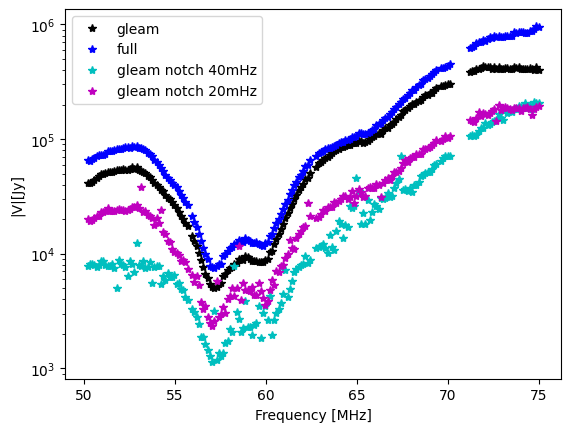

In [31]:
plt.figure()
plot_redundant_abs(file_name=path_data+"abs_calibrated_data_gleam_", uvh5name=uvh5name, label="gleam", colour='k*')
plot_redundant_abs(file_name=path_data+"abs_calibrated_data_full_", uvh5name=uvh5name, label="full", colour='b*')
plot_redundant_abs(file_name=path_data+"abs_calibrated_data_"+filter_name_2+"_gleam_", label="gleam notch 40mHz", uvh5name=uvh5name, colour='c*')
plot_redundant_abs(file_name=path_data+"abs_calibrated_data_"+filter_name_5+"_gleam_", label="gleam notch 20mHz", uvh5name=uvh5name, colour='m*')
plt.legend()
# plt.savefig("paper_figures/visibility_amp_notch_filter.pdf")


In [ ]:
filter_name_2

## Gain analysis

In [32]:
N=100
def extract_antenna_averaged_gains(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name):
    gains_gleam =[]
    k=0
    for x in range (N):
        
        n=k+x
        if (n!=64 and n!=63 and n!=22 and n!=21 and n!=19 and n!=18): 
            i=4*n
            g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy",allow_pickle=True).item()
            gain_temp=[]
            for ant in g1:
                for t in range (1):
                    gain_temp.append(g1[ant][t,:])
            gain_temp=np.array(gain_temp)
            gain_ave=np.mean(np.abs(gain_temp), axis=0)
            gains_gleam.append(gain_ave)

    for x in range (N):
        n=k+x
        if (n!=64 and n!=63 and n!=22 and n!=21 and n!=19 and n!=18): 
            i=4*n+1
            g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_1h_"+spw+".npy",allow_pickle=True).item()
            gain_temp=[]
            for ant in g1:
                for t in range (1):
                    gain_temp.append(g1[ant][t,:])
            gain_temp=np.array(gain_temp)
            gain_ave=np.mean(np.abs(gain_temp), axis=0)
            gains_gleam.append(gain_ave)    
    

    for x in range (N):
        n=k+x
        if (n!=64 and n!=63 and n!=22 and n!=21 and n!=19 and n!=18): 
            i=4*n+2
                   
            g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_2h_"+spw+".npy",allow_pickle=True).item()
            gain_temp=[]
            for ant in g1:
                for t in range (1):
                    gain_temp.append(g1[ant][t,:])
            gain_temp=np.array(gain_temp)
            gain_ave=np.mean(np.abs(gain_temp), axis=0)
            gains_gleam.append(gain_ave) 

    for x in range (N):
        n=k+x  
       
        if n!=4 and n!=5 and n!=6 and n!=19 and n!=18:
    
            i=4*n+3
            g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_3h_"+spw+".npy",allow_pickle=True).item()
            gain_temp=[]
            for ant in g1:
                for t in range (1):
                    gain_temp.append(g1[ant][t,:])
            gain_temp=np.array(gain_temp)
            gain_ave=np.mean(np.abs(gain_temp), axis=0)
            gains_gleam.append(gain_ave)    
            
    gains_gleam=np.array(gains_gleam)

    return gains_gleam

gains_gleam_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name)
gains_gleam_filter_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name_5+"_gleam_flagged_abscal", N=N,uvh5name=uvh5name)
gains_full_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_full_flagged_abscal", N=N,uvh5name=uvh5name)
gains_full_filter_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name_5+"_full_flagged_abscal", N=N,uvh5name=uvh5name)

gains_full_filter_notch_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name_2+"_full_flagged_abscal", N=N,uvh5name=uvh5name)
gains_gleam_filter_notch_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name_2+"_gleam_flagged_abscal", N=N,uvh5name=uvh5name)

def flag_rfi(gains, f_0, f_1, freqs):
    index_flag=np.where((freqs>=f_0 ) & (freqs<=f_1))
    for t in range (gains.shape[0]):
        gains[t,:][index_flag]=np.ones(gains[t,:][index_flag].shape)*np.nan
    # print(gains[index_flag])
    return gains


flag_low=69.85
flag_high=71.20
gains_gleam=flag_rfi(gains=gains_gleam_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)
gains_gleam_filter=flag_rfi(gains=gains_gleam_filter_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)
gains_full=flag_rfi(gains=gains_full_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)
gains_full_filter=flag_rfi(gains=gains_full_filter_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)   

gains_full_filter_notch=flag_rfi(gains=gains_full_filter_notch_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs) 
gains_gleam_filter_notch=flag_rfi(gains=gains_gleam_filter_notch_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs) 

In [33]:
filter_name, filter_name_5, N

('Main_lobe_20_mHz', 'Notch_filter_20_mHz', 100)

Text(0, 0.5, '|g|')

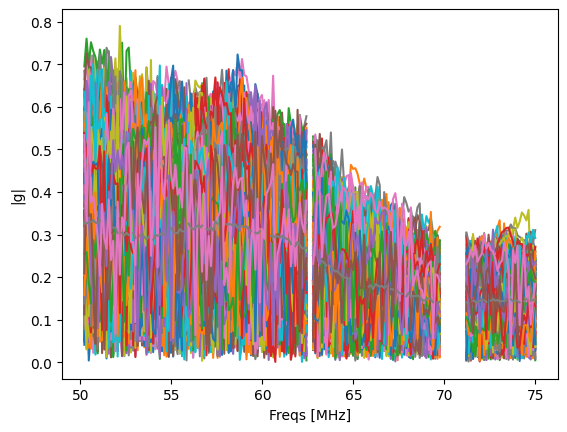

In [34]:
x,y=0,205
for i in range (gains_gleam.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

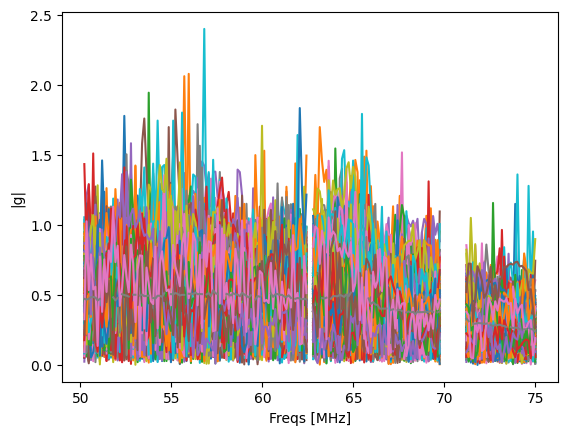

In [35]:
x,y=0,205
for i in range (gains_gleam.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter_notch[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter_notch[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

In [36]:


def extract_antenna_gains_all_times(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name):
    gains_gleam =[]
    for i in range (N):
        g1=np.load(path_data+gain_name+uvh5name[i]+".npy",allow_pickle=True).item()
        
        for ant in g1:
            gain_temp=[]
            for t in range (2):
                gain_temp.append(g1[ant][t,:])
            gain_temp=np.array(gain_temp)
            gains_gleam.append(np.mean(gain_temp,axis=0))
    gains_gleam=np.array(gains_gleam) 

    return gains_gleam    

def produce_plots_every_n_time(n=10, N=N, gains=""):
    for m in range (int(N/n)):
        for i in range (N):
        
            if n*m<=i and i<(m+1)*n:
                if i==m*n:
                    plt.figure(figsize=(5,2))
                plt.plot(freqs[50:-1],gains[i,:][50:-1])
                plt.xlabel("Freqs [MHz]")
                plt.ylabel("|g|")

def produce_plots_colour_every_n_time(n=10, N=N, gains=""):
    cl_al=[c['color'] for c in plt.rcParams['axes.prop_cycle']]
    for m in range (int(N/n)):
        for i in range (N):
        
            if n*m<=i and i<(m+1)*n:
                if i==m*n:
                    #plt.figure(figsize=(5,2))
                    cl=cl_al[m]
                plt.plot(freqs[50:-1],gains[i,:][50:-1], cl)
                plt.xlabel("Freqs [MHz]")
                plt.ylabel("|g|")                
        
def produce_average_plots_every_n_time(n=10, N=N, gains="", lsts=lsts):
    for m in range (int(N/n)):
        gain_temp=[]
        for i in range (N):
            
            if n*m<=i and i<(m+1)*n:
                
                if i==m*n:
                    gain_temp.append(gains[i,:][50:-1])
        gain_temp=np.array(gain_temp)
        gains_ave=np.mean(gain_temp, axis=0)
                
        plt.plot(freqs[50:-1],gains_ave, label="lst ="+str(np.round(lsts[m*n],2)))    
        plt.xlabel("Freqs [MHz]")
        plt.ylabel("|g|")
        plt.legend()

# Subset of freqs

Text(0, 0.5, '|g|')

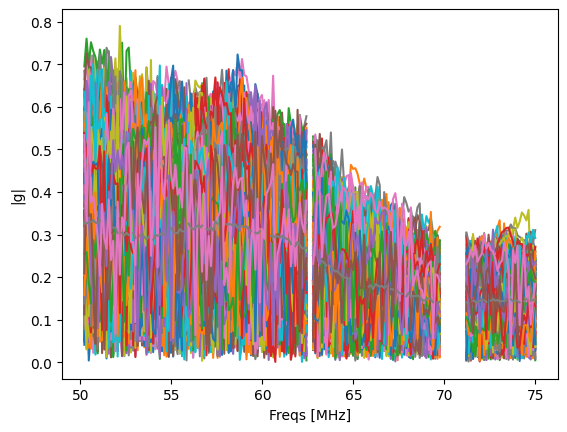

In [37]:
x,y=0,205
for i in range (gains_gleam.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

In [38]:
len(gains_gleam)


377

Text(0, 0.5, '|g|')

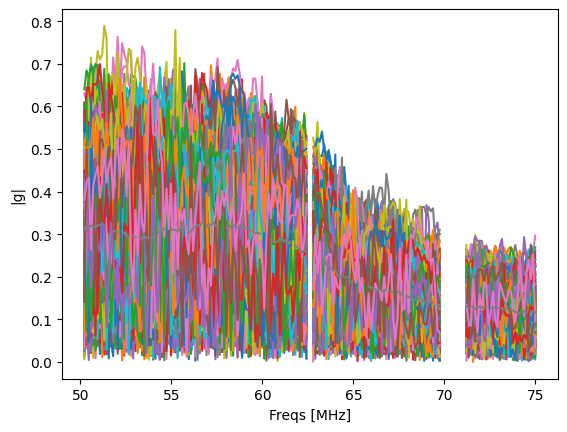

In [39]:

for i in range (gains_full.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_full[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

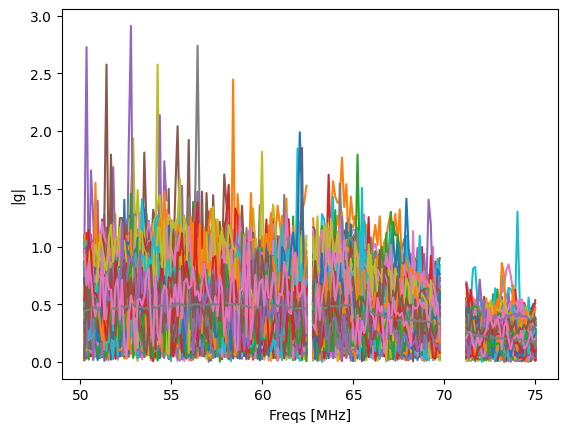

In [40]:

for i in range (gains_full_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_full_filter_notch[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full_filter_notch[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

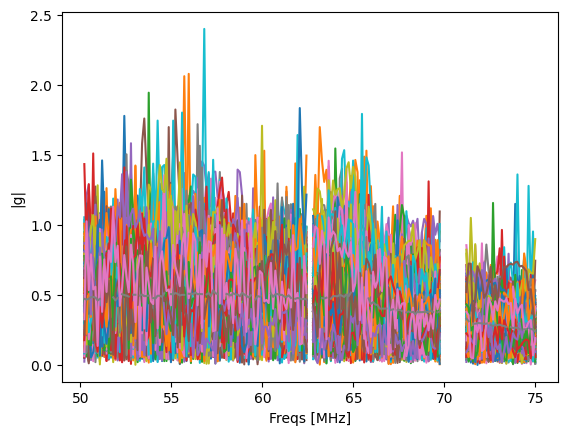

In [41]:

for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter_notch[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter_notch[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

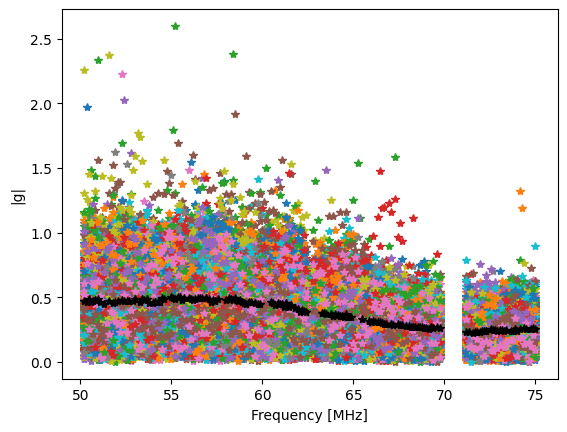

In [42]:
for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter[i,x:y]),'*')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter[:,x:y]), axis=0)),'k*')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
# plt.savefig("paper_figures/gains_notch.pdf")

Text(0, 0.5, '|g|')

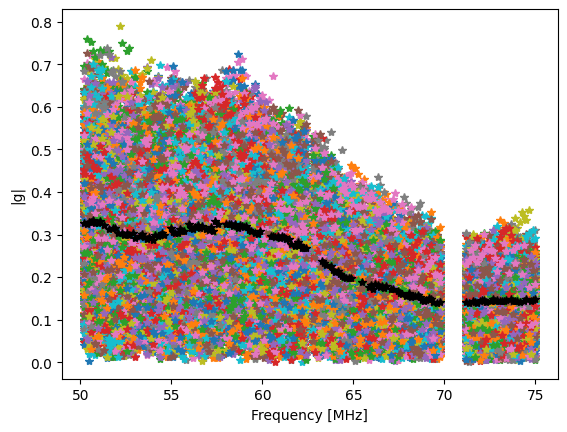

In [43]:
for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam[i,x:y]),'*')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)),'k*')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
# plt.savefig("paper_figures/gains_no_filter_gleam.pdf")

Text(0, 0.5, '|g|')

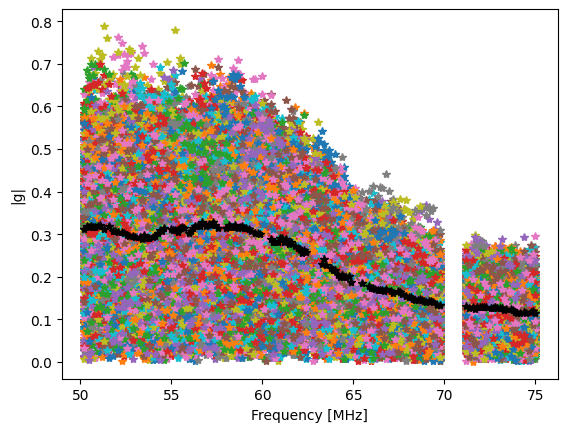

In [44]:
for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_full[i,x:y]),'*')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full[:,x:y]), axis=0)),'k*')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
# plt.savefig("paper_figures/gains_no_filter_full.pdf")

Text(0, 0.5, '|g|')

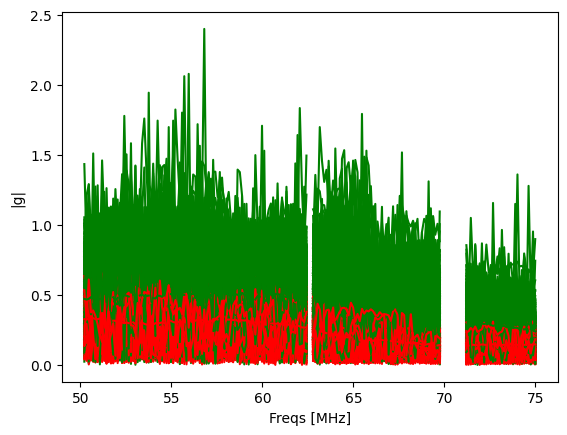

In [45]:

for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter_notch[i,x:y]), 'g')
    plt.plot(freqs[x:y],np.abs(gains_gleam[i,x:y]), 'r')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter_notch[:,x:y]), axis=0)),'g')  
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)),'r')  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

## Avarage gain amplitude

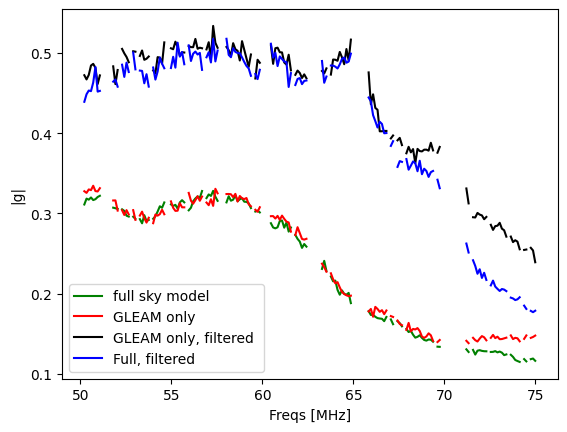

In [46]:
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full[:,x:y]), axis=0)),'g', label="full sky model") 
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)),'r', label="GLEAM only") 
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter_notch[:,x:y]), axis=0)),'k', label="GLEAM only, filtered ") 
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full_filter_notch[:,x:y]), axis=0)),'b', label="Full, filtered ") 
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")
plt.legend()

Text(0, 0.5, '|g|')

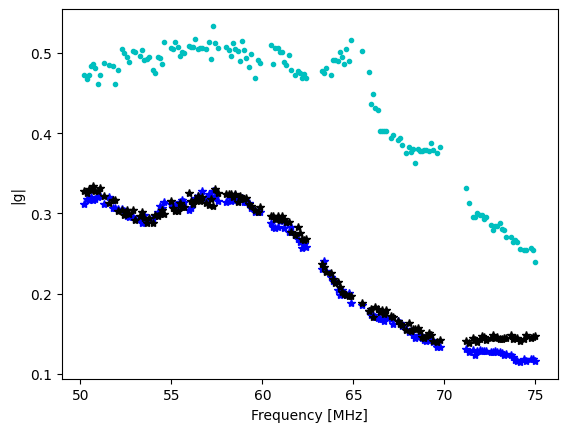

In [47]:
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0)),'c.', label="gleam, notch") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full), axis=0)),'b*', label="GLEAM only") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0)),'k*', label="gleam, mainlobe ") 
# plt.plot(freqs,np.abs(np.mean(np.abs(gains_full_filter_notch), axis=0)),'y.', label="Full, filtered ") 
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
# plt.savefig("paper_figures/gains_average_notch_filter.pdf")

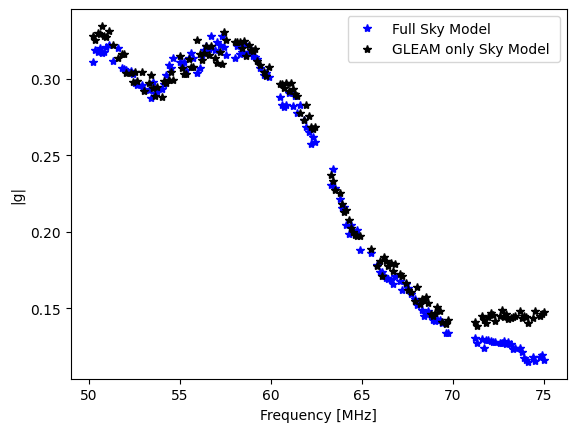

In [56]:
# plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0)),'c.', label="gleam, notch") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full), axis=0)),'b*', label="Full Sky Model") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0)),'k*', label="GLEAM only Sky Model ") 
# plt.plot(freqs,np.abs(np.mean(np.abs(gains_full_filter_notch), axis=0)),'y.', label="Full, filtered ") 
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
plt.legend()
# plt.savefig("paper_figures/gains_average_no_filter.pdf")

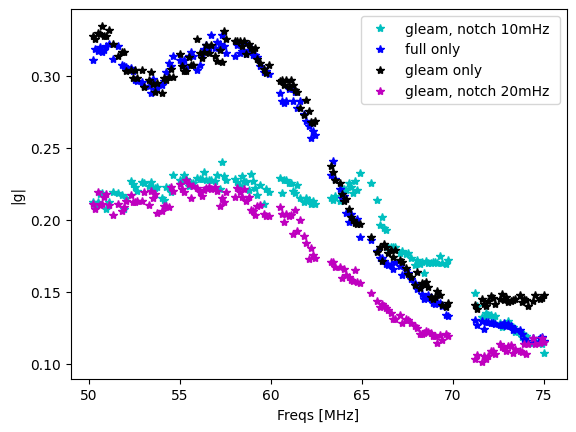

In [59]:
c=0.45
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0))*c,'c*', label="gleam, notch 10mHz") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full), axis=0)),'b*', label="full only") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0)),'k*', label="gleam only ") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter), axis=0))*c,'m*', label="gleam, notch 20mHz ") 
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")
plt.legend()

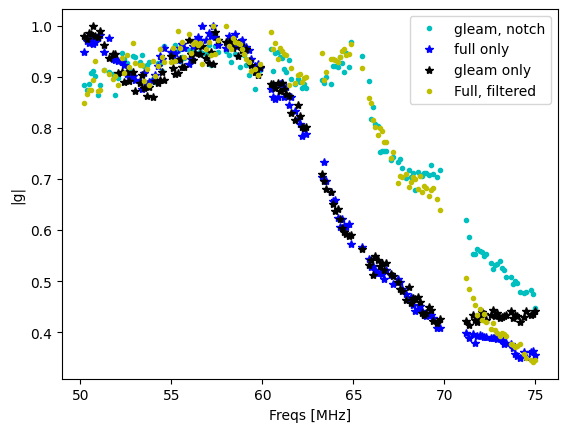

In [60]:
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0))),'c.', label="gleam, notch") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_full), axis=0))),'b*', label="full only") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_gleam), axis=0))),'k*', label="gleam only ") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full_filter_notch), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_full_filter_notch), axis=0))),'y.', label="Full, filtered ") 
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")
plt.legend()

## Delay Transform average gain

In [51]:
def fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=""):

    gains=np.abs(gains_raw)
    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>=0)
    tau_pos=tau[index]
    window=np.ones(gains.shape)
    for i in range(window.shape[0]):
        window[i,:]=windows.blackmanharris(len(freqs))
    
   
    gains_full_fitted=[]
    for t in range (gains.shape[0]):
        gains_time_no_nans=gains[t,:][~np.isnan(gains[t,:])]
        freq_no_nans=freqs[~np.isnan(gains[t,:])]
        coeffs = np.polyfit(freq_no_nans, gains_time_no_nans, 6)
        poly = np.poly1d(coeffs)
        x_fit=freqs
        y_fit=poly(x_fit)
        gains_fitted=[]
        for i in range (gains.shape[1]):
            if np.isnan(gains[t,i]):
                gains_fitted.append(poly(x_fit[i]))
            else:
                gains_fitted.append(gains[t,i])
        gains_fitted=np.array(gains_fitted)

        gains_full_fitted.append(gains_fitted)
    gains_full_fitted=np.array(gains_full_fitted)
    print(gains_full_fitted.shape)
    g0_delay=[]
    for i in range (gains_full_fitted.shape[0]-1):
        g1=np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted)))[i,:]
        g2=np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted)))[i+1,:]
        g0_delay.append(g1*np.conjugate(g2))
    g0_delay=np.array(g0_delay)
    
    g0_delay=np.mean(g0_delay,axis=0)[index]
    
    return np.mean(gains_full_fitted, axis=0), gains_full_fitted,np.abs(g0_delay), tau_pos





In [63]:
def produce_plots_delay(n,N):
    
    x,y=0,205
    gains_full_ave, g0, full_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full[n:N,x:y])
    gains_gleam_ave, g1, gleam_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam[n:N,x:y])
    gains_gleam_filter_ave, g2, gleam_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam_filter[n:N,x:y])
    gains_full_filter_ave, g3, full_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full_filter[n:N,x:y])
    gains_full_filter_ave_notch, g4, full_filter_notch_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full_filter_notch[n:N,x:y])
    gains_gleam_filter_ave_notch, g5, gleam_filter_notch_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam_filter_notch[n:N,x:y])
    
    
    
    # plt.plot(freqs[x:y], gains_full_ave,'k', label="full")
    # plt.plot(freqs[x:y], gains_gleam_ave, 'r', label="gleam")
    # plt.plot(freqs[x:y], gains_gleam_filter_ave, 'g', label="gleam filter")
    # plt.plot(freqs[x:y], gains_full_filter_ave, 'm', label="full filter")
    # plt.plot(freqs[x:y], gains_gleam_filter_ave_notch, 'c', label="notch gleam filter")
    # plt.plot(freqs[x:y], gains_full_filter_ave_notch, 'b', label="notch full filter")
    
    # plt.xlabel("Freq[MHz]")
    # plt.ylabel("$|g(\\nu)|$")
    # plt.legend()
    plt.figure()
    # print(tau_pos, gleam_delay)
    # plt.semilogy(tau_pos, full_delay,'k')
    # plt.semilogy(tau_pos, gleam_delay,'r')
    # plt.semilogy(tau_pos, gleam_filter_delay,'g')
    # plt.semilogy(tau_pos, full_filter_delay,'m')

    plt.semilogy(tau_pos, full_delay/np.max(full_delay),'b')
    plt.semilogy(tau_pos, gleam_delay/np.max(gleam_delay),'k')
    plt.semilogy(tau_pos, gleam_filter_delay/np.max(gleam_filter_delay),'g')
    # plt.semilogy(tau_pos, full_filter_delay/np.max(full_filter_delay),'m')
    # plt.semilogy(tau_pos, full_filter_notch_delay/np.max(full_filter_notch_delay),'y')
    plt.semilogy(tau_pos, gleam_filter_notch_delay/np.max(gleam_filter_notch_delay),'c')
    plt.xlabel("Delay $\\tau$ [ns]")
    plt.ylabel("$|g(\\tau)|$")
    plt.xlim([0,600])
    # plt.savefig("paper_figures/gains_delay_space_notch_filter.pdf")

(377, 205)
(377, 205)
(377, 205)
(377, 205)
(377, 205)
(377, 205)


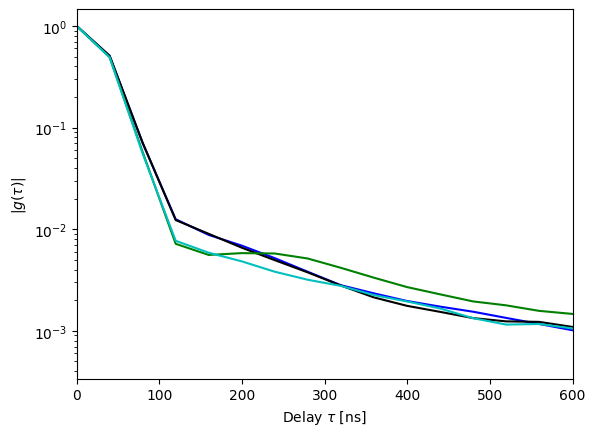

In [64]:
produce_plots_delay(n=0,N=400)

(70, 205)
(70, 205)
(70, 205)
(70, 205)
(70, 205)
(70, 205)


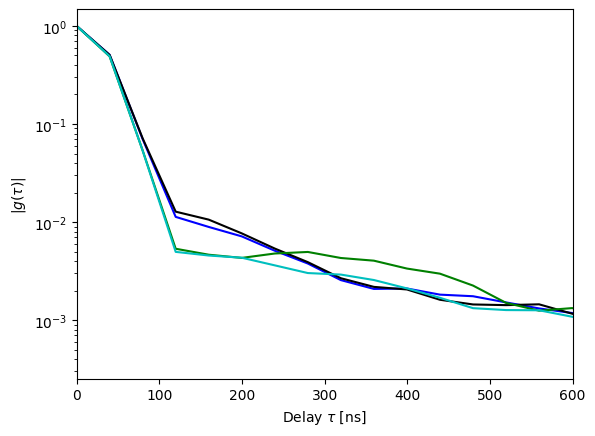

In [65]:
produce_plots_delay(n=0,N=70)

(377, 205)
(377, 205)
(377, 205)
(377, 205)
(377, 205)
(377, 205)


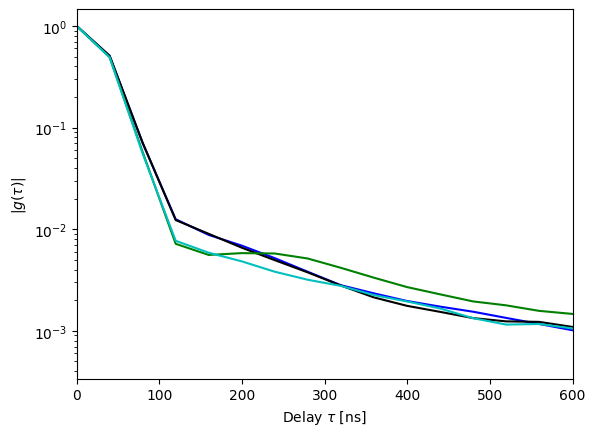

In [66]:
produce_plots_delay(n=0,N=len(gains_full))

(247, 205)
(247, 205)
(247, 205)
(247, 205)
(247, 205)
(247, 205)


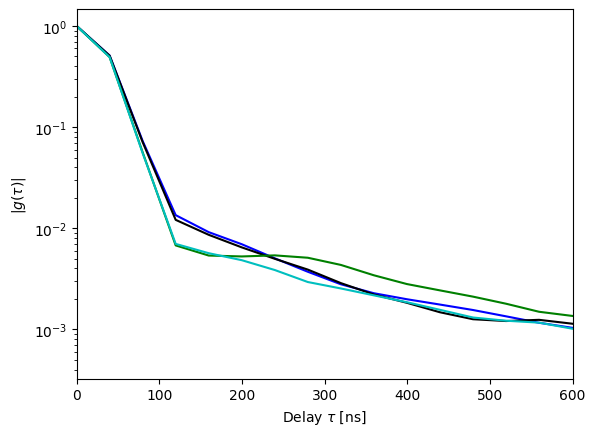

In [67]:
produce_plots_delay(n=3,N=250)

(20, 205)
(20, 205)
(20, 205)
(20, 205)
(20, 205)
(20, 205)


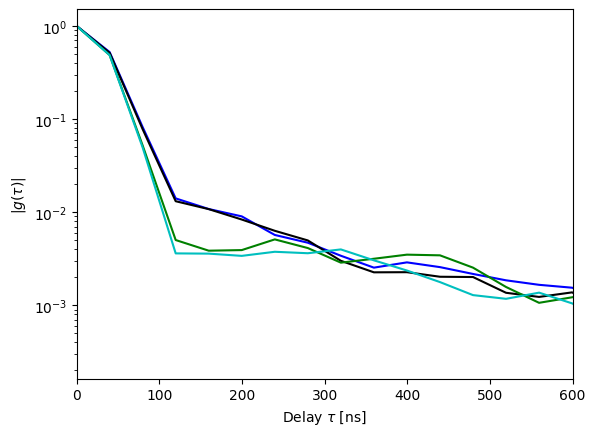

In [68]:
produce_plots_delay(n=50,N=70)

(100, 205)
(100, 205)
(100, 205)
(100, 205)
(100, 205)
(100, 205)


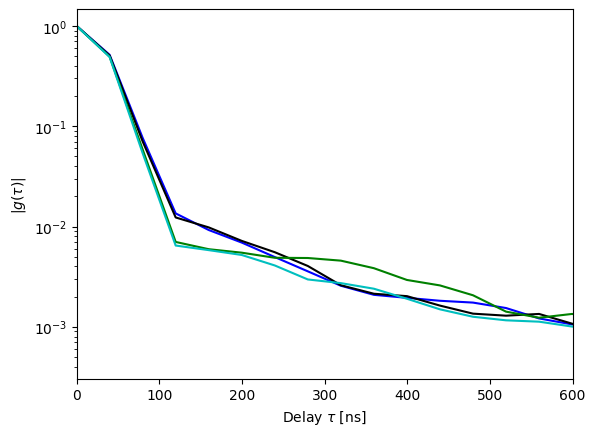

In [69]:
produce_plots_delay(n=0,N=100)

## Chis-sqaure

In [ ]:
N=90
chis_no_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_redcal_"+uvh5name[i]+".npy")

    chis_no_filer.append(g1)
chis_no_filer=np.array(chis_no_filer) 

In [ ]:
chis_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_Notch_filter_40_mHz_redcal_"+uvh5name[i]+".npy")

    chis_filer.append(g1)
chis_filer=np.array(chis_filer) 

In [ ]:
plt.figure(figsize=(6, 5))
plt.hist(np.abs(chis_no_filer.ravel()), bins=101, range=(0, 2), density=True, alpha=0.75,label="no coupling")
plt.hist(np.abs(chis_filer.ravel()), bins=101, range=(0, 2), density=True, alpha=0.75,label="filter")
x = np.linspace(0.8, 1.2, 1000)
#plt.plot(x, stats.chi2.pdf(x * 2*dof, 2*dof) * 2*dof, c='k', ls='--', lw=2,label="$\chi_k^2$ (kx)/k ")
plt.xlabel(r'reduced $\chi^2$', fontsize=16)
plt.ylabel('probability density', fontsize=16)
plt.legend()

In [ ]:
bls_select=[]
for i in range (len(baseline)):
    bls_select.append((baseline[i][0],baseline[i][1]))

In [ ]:
path_data_model="/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/"
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"

hd= io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5")
# hd2 = hc.io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h_test.uvh5")
freqs = hd.freq_array
antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
antpos_d = dict(zip(ants, antpos))

bl_lens = {bl: np.linalg.norm(antpos_d[bl[1]]-antpos_d[bl[0]]) for bl in hd.get_antpairs()}   
# downselect to maximum baseline length (to reduce computational load in calibration)
bls = []
for bl in list(hd.get_antpairs()):
    # max 40 m baseline cut (also cut autos)
    bl_len = np.linalg.norm(antpos_d[bl[1]] - antpos_d[bl[0]])
    if bl_len > 0:
        bls.append(bl[:2])   

time=np.unique(hd.time_array)[0]
# only load a couple of times and frequencies
pol=hd.polarization_array
hd.read(polarizations=pol[0],frequencies=freqs, times=time)
# hd2.read(polarizations=pol[0],frequencies=freqs,times=time)

# hd.conjugate_bls()
# hd._determine_blt_slicing()
# hd._determine_pol_indexing()

# hd2.conjugate_bls()
# hd2._determine_blt_slicing()
# hd2._determine_pol_indexing()

 
hd.x_orientation = 'east'
# hd2.x_orientation = 'east'

hd.select(bls=bls)
  
    # load datacontainer
data, _, _ = hd.build_datacontainers() #xtalk raw data
# model, _, _ = hd2.build_datacontainers() # x-talk model
   


 



        
        




In [ ]:
pol=hd.polarization_array

In [ ]:
for key in data:
    plt.plot(np.abs(data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
reds = hc.redcal.get_reds(antpos_d, pols=['ee'])
red_data=[]
for red_g in reds:
    bl_group=[]
    for bl in red_g:
        if bl in list(data.keys()):
            bl_group.append(bl)    
    if len(bl_group)>0:   
        red_data.append(bl_group)    

# rc = hc.redcal.RedundantCalibrator(filtered_reds)
rc = hc.redcal.RedundantCalibrator(red_data)


In [ ]:
#get redundant baseline groups in data

Nrms=1e-4

# get noise wgts (use whatever noise RMS you put into the data)
noise_wgts = {k: np.ones_like(data[k], dtype=float) / Nrms**2 for k in data}


#     # perform logcal
logcal_meta, logcal_sol = rc.logcal(data)
hc.redcal.make_sol_finite(logcal_sol)
#remove redcal degeneracies from solution
# logcal_sol = rc.remove_degen(logcal_sol)
#get gains and model visibilities
# logcal_gains, logcal_vis = hc.redcal.get_gains_and_vis_from_sol(logcal_sol)



In [ ]:
#perform omnical (lincal)
conv_crit = 1e-10
maxiter = 500
gain = 0.4
lincal_meta, lincal_sol = rc.omnical(data, logcal_sol, wgts=noise_wgts, conv_crit=conv_crit,
                                 maxiter=maxiter, gain=gain)




In [ ]:
for ant in logcal_sol.gains:

    plt.plot(np.abs(logcal_sol.gains[ant])[0])

In [ ]:
for ant in lincal_sol.gains:

    plt.plot(np.abs(lincal_sol.gains[ant])[0])

In [ ]:
for ant in lincal_sol.vis:

    plt.plot(np.abs(lincal_sol.vis[ant])[0])

In [ ]:
# figure out appropriate model times to load
matched_model_files=["/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/single_pol_model_combined_2h_test.uvh5"]
hdm = io.HERAData(matched_model_files)
times=np.unique(hdm.time_array)
hdm.read(polarizations=pol[0], times=times[0], frequencies=freqs)
model_data,_,_=hdm.build_datacontainers() 


In [ ]:
data_bls, model_bls, data_to_model_bl_map=abscal.match_baselines(data_bls=data.keys(), model_bls=model_data.keys(), data_antpos=data.antpos,model_antpos= model_data.antpos, pols=['nn'], data_is_redsol=True,
    model_is_redundant=True, verbose=True)

In [ ]:
model_data_modi=copy.deepcopy(data)
for i in range (len(model_bls)):
    model_data_modi[data_bls[i]]=model_data[model_bls[i]]


In [ ]:
model_data_modi[data_bls[0]]


In [ ]:
model_data[model_bls[0]]

In [ ]:
# calibration with lincal gains
redcal_data = copy.deepcopy(data)
hc.apply_cal.calibrate_in_place(redcal_data, lincal_sol.gains)

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(redcal_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
# calibration with lincal gains
calibrated_data = copy.deepcopy(redcal_data)

In [ ]:
rc_flags = {k: np.zeros_like(lincal_sol.gains[k], dtype=bool) for k in lincal_sol.gains}


In [ ]:
noise_wgts = {k: np.ones_like(redcal_data[k], dtype=float)  for k in redcal_data}

for k in data:

    if k not in data_bls: 

        noise_wgts[k] = np.ones(noise_wgts[k].shape)*1e-40


In [ ]:
abscal_gains = hc.abscal.post_redcal_abscal(model_data_modi, calibrated_data, noise_wgts, rc_flags, verbose=False)

In [ ]:
total_gains = hc.abscal.merge_gains([lincal_sol.gains, abscal_gains])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(abscal_gains[ant])[0])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(total_gains[ant])[0])

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(calibrated_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
hc.abscal.post_redcal_abscal??